# Regime Strategy — TEST Backtest (held-out)

Final out-of-sample evaluation on the TEST window. Uses cached regressor /
tech-features / classifier from `MeanRev_vs_Momentum.ipynb`.

**Gates chosen on VAL** (single decision, no further tuning):
- Primary: `rz=1.5, conf=0.45, mre=0.5` (VAL Sharpe 1.33, 90 entries — most robust)
- Reference: baseline `rz=1.5, conf=0.55, mre=0.30` (the TRAIN-config gates)
- Reference: high-conviction `rz=1.5, conf=0.65, mre=0.30` (VAL Sharpe 1.62, 13 entries)

We also include a small per-sector report. **No grid search on TEST.**

In [1]:
# Cell 2 — Imports, cache, seeds
import os, sys, pickle, warnings
import random as _random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
%matplotlib inline

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'strategy').exists():
    cand = Path(r'C:\algo-trading-project')
    if cand.exists():
        PROJECT_ROOT = cand
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

SEED = 42
_random.seed(SEED); np.random.seed(SEED)

CACHE_DIR = Path('outputs/regime_cache')
REGRESSOR_CACHE = CACHE_DIR / 'regressor_outputs.pkl'
TECH_CACHE      = CACHE_DIR / 'tech_features.pkl'
CLF_CACHE       = CACHE_DIR / 'regime_clf.pkl'
for p in [REGRESSOR_CACHE, TECH_CACHE, CLF_CACHE]:
    if not p.exists():
        raise FileNotFoundError(f'Missing cache: {p}. Run MeanRev_vs_Momentum.ipynb first.')
print(f'Cache OK: {[p.name for p in [REGRESSOR_CACHE, TECH_CACHE, CLF_CACHE]]}')

Cache OK: ['regressor_outputs.pkl', 'tech_features.pkl', 'regime_clf.pkl']


In [2]:
# Cell 3 — Project setup, splits, TEST window
from config import SECTORS
from strategy.strategy_config import StrategyConfig
from strategy.pipeline import StrategyPipeline
from strategy.splits import chrono_split

cfg = StrategyConfig(force_recompute=False, make_plots=False)
pipeline = StrategyPipeline(cfg)
md = pipeline.load_data()
split = chrono_split(md.prices.index, cfg)

train_idx = pd.DatetimeIndex(split.train_idx).sort_values()
val_idx   = pd.DatetimeIndex(split.val_idx).sort_values()
test_idx  = pd.DatetimeIndex(split.test_idx).sort_values()

TARGETS = {s['name']: {'etf': etf, 'target': s['target'], 'predictors': s['predictors']}
           for etf, s in SECTORS.items()}

print(f'TRAIN: {train_idx[0].date()} -> {train_idx[-1].date()} | n={len(train_idx)}')
print(f'VAL  : {val_idx[0].date()} -> {val_idx[-1].date()} | n={len(val_idx)}')
print(f'TEST : {test_idx[0].date()} -> {test_idx[-1].date()} | n={len(test_idx)}')

[cache] HIT  market_data__4adce62649ea.pkl
TRAIN: 2021-01-04 -> 2024-04-03 | n=817
VAL  : 2024-04-04 -> 2025-05-05 | n=272
TEST : 2025-05-06 -> 2026-06-04 | n=272


In [3]:
# Cell 4 — Load cached artifacts, build decision panel, restrict to TEST
with open(REGRESSOR_CACHE, 'rb') as f:
    regressor_outputs = pickle.load(f)
tech_panel = pd.read_pickle(TECH_CACHE)
with open(CLF_CACHE, 'rb') as f:
    clf_blob = pickle.load(f)
clf = clf_blob['model']
TECH_FEATURE_COLS = clf_blob['features']
print(f'Loaded {len(regressor_outputs)} sectors, '
      f'{len(tech_panel):,} tech rows, {len(TECH_FEATURE_COLS)} clf features')

_FROM_IDX = {0: -1, 1: 0, 2: 1}
panel_clf = tech_panel.copy()
panel_clf['date'] = pd.to_datetime(panel_clf['date'])
X_all = panel_clf[TECH_FEATURE_COLS].astype(float)
proba_all = clf.predict_proba(X_all)
panel_clf['regime_pred'] = np.array([_FROM_IDX[i] for i in clf.predict(X_all)])
panel_clf['P_MR']        = proba_all[:, 0]
panel_clf['P_NEUTRAL']   = proba_all[:, 1]
panel_clf['P_MOM']       = proba_all[:, 2]
panel_clf['regime_conf'] = proba_all.max(axis=1)

decision_rows = []
for sector, info in TARGETS.items():
    tgt = info['target']
    if sector not in regressor_outputs:
        continue
    reg = regressor_outputs[sector]
    clf_slice = panel_clf[panel_clf['sector'] == sector][
        ['date','regime_pred','regime_conf','P_MR','P_NEUTRAL','P_MOM']
    ].set_index('date')
    df = pd.DataFrame({
        'residual_z':       reg['residual_z'],
        'predicted_return': reg['predicted_return'],
        'next_ret':         reg['next_ret'],
        'price':            md.prices[tgt],
    }).join(clf_slice, how='left')
    df['sector'] = sector; df['target'] = tgt; df['date'] = df.index
    decision_rows.append(df.reset_index(drop=True))

decision_panel = pd.concat(decision_rows, ignore_index=True)
decision_panel = decision_panel.dropna(subset=['residual_z','regime_pred','next_ret']).reset_index(drop=True)
decision_panel = decision_panel.sort_values(['date','sector']).reset_index(drop=True)

test_panel = decision_panel[decision_panel['date'].isin(test_idx)].copy()
print(f'\nTEST decision panel: {len(test_panel):,} rows | '
      f'{test_panel["date"].min().date()} -> {test_panel["date"].max().date()} | '
      f'{test_panel["date"].nunique()} dates')
reg_map = {-1:'MEAN_REV',0:'NEUTRAL',1:'MOMENTUM'}
print('\nRegime distribution (TEST):')
print(test_panel['regime_pred'].map(reg_map).value_counts().to_string())
print('\nresidual_z stats (TEST):')
print(test_panel['residual_z'].describe().round(3).to_string())

Loaded 10 sectors, 13,610 tech rows, 16 clf features



TEST decision panel: 2,710 rows | 2025-05-06 -> 2026-06-03 | 271 dates

Regime distribution (TEST):
regime_pred
NEUTRAL     1765
MOMENTUM     496
MEAN_REV     449

residual_z stats (TEST):
count    2710.000
mean        0.040
std         1.295
min        -4.706
25%        -0.936
50%         0.038
75%         1.005
max         3.742


In [4]:
# Cell 5 — PM simulator + metrics (same logic as MeanRev/VAL)
PM_COST_BPS = 5.0 / 1e4

def regime_pm_simulate(panel, rz_thr, conf_thr, mr_exit,
                       max_hold=10, stop_loss=-0.02, take_profit=0.03,
                       pred_ret_thr=0.001, cost_bps=PM_COST_BPS):
    state, seq, rows = {}, {}, []
    for (date, sector), grp in panel.groupby(['date','sector'], sort=True):
        r = grp.iloc[0]
        st = state.get(sector, dict(position=0, days_in=0, entry_price=np.nan,
                                    trade_pnl=0.0, trade_id=None))
        prev_pos = st['position']
        rz, regm, conf = float(r['residual_z']), int(r['regime_pred']), float(r['regime_conf'])
        prr  = float(r['predicted_return']) if pd.notna(r['predicted_return']) else 0.0
        nr   = float(r['next_ret']) if pd.notna(r['next_ret']) else 0.0
        price = float(r['price']) if pd.notna(r['price']) else np.nan
        action, desired = 'HOLD', prev_pos
        if prev_pos != 0:
            st['days_in'] += 1
            if (st['days_in'] >= max_hold or abs(rz) <= mr_exit
                or st['trade_pnl'] <= stop_loss or st['trade_pnl'] >= take_profit):
                desired = 0; action = 'EXIT'
        if desired == 0 and abs(rz) >= rz_thr and regm != 0 and conf >= conf_thr:
            if regm == -1:
                if rz < 0:  desired, action = 1, 'ENTER_LONG'
                else:       desired, action = -1, 'ENTER_SHORT'
            else:
                if rz > 0 and prr > -pred_ret_thr: desired, action = 1, 'ENTER_LONG'
                elif rz < 0 and prr < pred_ret_thr: desired, action = -1, 'ENTER_SHORT'
        turnover = abs(desired - prev_pos)
        gross = desired * nr; net = gross - turnover * cost_bps
        is_entry = action.startswith('ENTER'); is_exit = (action == 'EXIT')
        if is_entry:
            seq[sector] = seq.get(sector, 0) + 1
            st = dict(position=desired, days_in=1, entry_price=price,
                      trade_pnl=net, trade_id=seq[sector])
        elif is_exit:
            st['trade_pnl'] += net
            st = dict(position=0, days_in=0, entry_price=np.nan, trade_pnl=0.0, trade_id=None)
        elif desired != 0:
            st['trade_pnl'] += net
        state[sector] = st
        rows.append({
            'date': date, 'sector': sector, 'target': r['target'],
            'residual_z': rz, 'regime_pred': regm, 'regime_conf': conf,
            'predicted_return': prr, 'next_ret': nr,
            'action': action, 'position': float(desired), 'prev_pos': float(prev_pos),
            'turnover': float(turnover),
            'gross_pnl': float(gross), 'net_pnl': float(net),
            'is_entry': bool(is_entry), 'is_exit': bool(is_exit),
        })
    return pd.DataFrame(rows)

def portfolio_metrics(td, periods_per_year=252):
    if td.empty: return pd.Series(dtype=float)
    daily = td.groupby('date')['net_pnl'].mean().sort_index()
    if daily.empty: return pd.Series(dtype=float)
    eq = (1.0 + daily).cumprod(); cum = float(eq.iloc[-1] - 1.0); n = len(daily)
    ann_ret = float((1.0 + cum) ** (periods_per_year / max(n,1)) - 1.0)
    ann_vol = float(daily.std(ddof=1) * np.sqrt(periods_per_year)) if n > 1 else np.nan
    sh = ann_ret / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol != 0 else np.nan
    dn = daily[daily < 0]
    dn_v = float(dn.std(ddof=1) * np.sqrt(periods_per_year)) if len(dn) > 1 else np.nan
    so = ann_ret / dn_v if dn_v and np.isfinite(dn_v) and dn_v != 0 else np.nan
    peak = eq.cummax(); mdd = float((eq / peak - 1.0).min())
    entries = td[td['is_entry']]
    return pd.Series({
        'trading_days': n, 'total_entries': int(len(entries)),
        'long_entries':  int((entries['position'] == 1).sum()),
        'short_entries': int((entries['position'] == -1).sum()),
        'active_days':   int((td['position'] != 0).sum()),
        'cumulative_return':     round(cum, 4),
        'annualized_return':     round(ann_ret, 4),
        'annualized_volatility': round(ann_vol, 4) if np.isfinite(ann_vol) else np.nan,
        'sharpe':                round(sh, 4) if np.isfinite(sh) else np.nan,
        'sortino':               round(so, 4) if np.isfinite(so) else np.nan,
        'max_drawdown':          round(mdd, 4),
        'win_rate_days':         round(float((daily > 0).mean()), 4),
        'avg_daily_pnl':         round(float(daily.mean()), 6),
    })

print('PM + metrics ready.')

PM + metrics ready.


In [5]:
# Cell 6 — Run the 3 fixed gate configurations on TEST
GATES = [
    ('TEST_primary_VAL_tuned',     1.5, 0.45, 0.50),
    ('TEST_baseline_TRAIN_config', 1.5, 0.55, 0.30),
    ('TEST_highconf_VAL_top',      1.5, 0.65, 0.30),
]
results = {}
rows = []
for tag, rz, c, mre in GATES:
    td = regime_pm_simulate(test_panel, rz, c, mre)
    m  = portfolio_metrics(td)
    results[tag] = (td, m)
    rows.append({'tag': tag, 'rz_thr': rz, 'conf_thr': c, 'mr_exit': mre, **m.to_dict()})
summary_test = pd.DataFrame(rows).set_index('tag')
print('=' * 78)
print('TEST RESULTS')
print('=' * 78)
print(summary_test[['rz_thr','conf_thr','mr_exit','total_entries','long_entries',
                    'short_entries','sharpe','sortino','cumulative_return',
                    'annualized_return','max_drawdown','win_rate_days']].to_string())

TEST RESULTS
                            rz_thr  conf_thr  mr_exit  total_entries  long_entries  short_entries  sharpe  sortino  cumulative_return  annualized_return  max_drawdown  win_rate_days
tag                                                                                                                                                                                  
TEST_primary_VAL_tuned         1.5      0.45      0.5          103.0          81.0           22.0  0.7275   1.0424             0.0327             0.0304       -0.0378         0.4207
TEST_baseline_TRAIN_config     1.5      0.55      0.3           61.0          52.0            9.0  0.4681   0.6003             0.0169             0.0157       -0.0302         0.3542
TEST_highconf_VAL_top          1.5      0.65      0.3           14.0          12.0            2.0  0.0300   0.0195             0.0004             0.0004       -0.0169         0.0849


In [6]:
# Cell 7 — Per-sector breakdown for the primary configuration
primary_tag = GATES[0][0]
td_primary, _ = results[primary_tag]
rows = []
for sec, g in td_primary.groupby('sector'):
    m = portfolio_metrics(g)
    rows.append({
        'sector': sec,
        'entries': int(m.get('total_entries', 0)),
        'long':    int(m.get('long_entries', 0)),
        'short':   int(m.get('short_entries', 0)),
        'sharpe':  m.get('sharpe', np.nan),
        'sortino': m.get('sortino', np.nan),
        'cum_ret': m.get('cumulative_return', np.nan),
        'max_dd':  m.get('max_drawdown', np.nan),
        'win_rate_days': m.get('win_rate_days', np.nan),
    })
per_sec = pd.DataFrame(rows).sort_values('sharpe', ascending=False, na_position='last')
print(f'Per-sector ({primary_tag}):')
print(per_sec.to_string(index=False))

Per-sector (TEST_primary_VAL_tuned):
          sector  entries  long  short  sharpe  sortino  cum_ret  max_dd  win_rate_days
     Health Care        8     3      5  1.5503   0.8004   0.2676 -0.0751         0.0775
  Consumer Disc.       17    15      2  1.4558   1.4242   0.2263 -0.1141         0.1365
      Financials        4     3      1  0.9107   0.3706   0.0536 -0.0346         0.0517
      Technology        9     6      3  0.3401   0.2027   0.0479 -0.1098         0.0627
       Utilities       15    12      3  0.0949   0.0689   0.0114 -0.0813         0.1218
       Materials       18    15      3 -0.0785  -0.0492  -0.0163 -0.1921         0.0959
Consumer Staples        6     5      1 -0.2204  -0.1294  -0.0162 -0.0913         0.0517
          Energy        8     7      1 -0.3742  -0.2245  -0.0420 -0.0990         0.0664
     Real Estate        9     7      2 -0.8778  -0.5113  -0.0705 -0.1063         0.0738
   Communication        9     8      1 -1.3477  -0.7830  -0.1390 -0.1534         0.

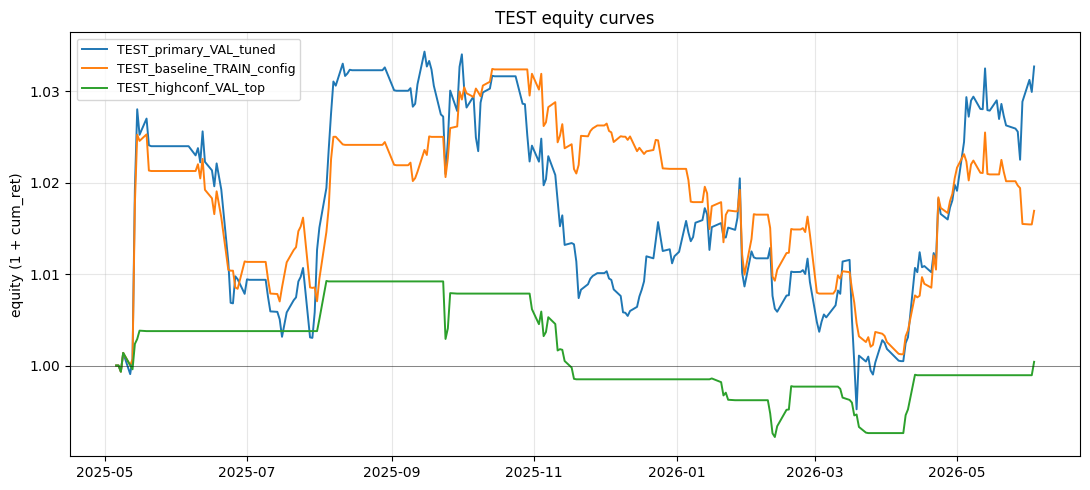

In [7]:
# Cell 8 — Equity curve plot (all 3 configs)
fig, ax = plt.subplots(figsize=(11, 5))
for tag, _, _, _ in GATES:
    td, _ = results[tag]
    if td.empty: continue
    daily = td.groupby('date')['net_pnl'].mean().sort_index()
    eq = (1.0 + daily).cumprod()
    ax.plot(eq.index, eq.values, label=tag, linewidth=1.4)
ax.axhline(1.0, color='black', linewidth=0.6, alpha=0.5)
ax.set_title('TEST equity curves')
ax.set_ylabel('equity (1 + cum_ret)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
# Cell 9 — Append TEST results to run_history
RUN_HISTORY = Path('outputs/tuning_cache/run_history.csv')
RUN_HISTORY.parent.mkdir(parents=True, exist_ok=True)
HIST_COLS = ['timestamp','source','tag','clf_trial','f1_val','rz_thr','conf','mr_exit',
             'total_entries','sharpe','sortino','cumulative_return',
             'annualized_return','annualized_volatility','max_drawdown',
             'win_rate_days','active_days']
ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
log_rows = []
for tag, rz, c, mre in GATES:
    m = results[tag][1]
    log_rows.append({
        'timestamp': ts, 'source': 'Regime_TEST', 'tag': tag,
        'clf_trial': None, 'f1_val': None,
        'rz_thr': rz, 'conf': c, 'mr_exit': mre,
        **{k: m.get(k) for k in HIST_COLS if k not in
           ('timestamp','source','tag','clf_trial','f1_val','rz_thr','conf','mr_exit')},
    })
new_df = pd.DataFrame([{c: r.get(c) for c in HIST_COLS} for r in log_rows])
if RUN_HISTORY.exists():
    prev = pd.read_csv(RUN_HISTORY)
    combined = pd.concat([prev, new_df], ignore_index=True)
else:
    combined = new_df
combined.to_csv(RUN_HISTORY, index=False)
print(f'Logged {len(new_df)} TEST rows. Total in history: {len(combined)}')

print('\nAll Regime_* runs (TRAIN/VAL/TEST):')
view = combined[combined['source'].str.startswith('Regime')][
    ['source','tag','rz_thr','conf','mr_exit','total_entries','sharpe','sortino',
     'cumulative_return','max_drawdown']
].copy()
print(view.to_string(index=False))

Logged 3 TEST rows. Total in history: 10

All Regime_* runs (TRAIN/VAL/TEST):
               source                            tag  rz_thr  conf  mr_exit  total_entries  sharpe  sortino  cumulative_return  max_drawdown
Regime_MeanRev_vs_Mom    rz1.5_conf0.45_mre0.3_train     1.5  0.45      0.3          230.0  0.1033   0.1140             0.0120       -0.0619
Regime_MeanRev_vs_Mom    rz1.5_conf0.55_mre0.3_train     1.5  0.55      0.3          132.0  0.9007   1.0421             0.0806       -0.0225
  Regime_VAL_baseline      rz1.5_conf0.55_mre0.3_VAL     1.5  0.55      0.3           49.0  0.3650   0.3498             0.0161       -0.0272
Regime_VAL_sweep_best rz1.5_conf0.65_mre0.5_VAL_BEST     1.5  0.65      0.5           13.0  1.6235   1.6660             0.0319       -0.0065
          Regime_TEST         TEST_primary_VAL_tuned     1.5  0.45      0.5          103.0  0.7275   1.0424             0.0327       -0.0378
          Regime_TEST     TEST_baseline_TRAIN_config     1.5  0.55      0.3 